In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [129]:
m = 4
n = 9

res_x = 1.0
res_y = 1.0

G = nx.Graph()
for i in range(m):
    for j in range(n):
        if i < m-1:
            G.add_edge((i,j),(i+1,j),label=str(i)+"_"+str(i+1)+"__"+str(j),res=res_x)
        if j < n-1:
            G.add_edge((i,j),(i,j+1),label=str(i)+"__"+str(j)+"_"+str(j+1),res=res_y)

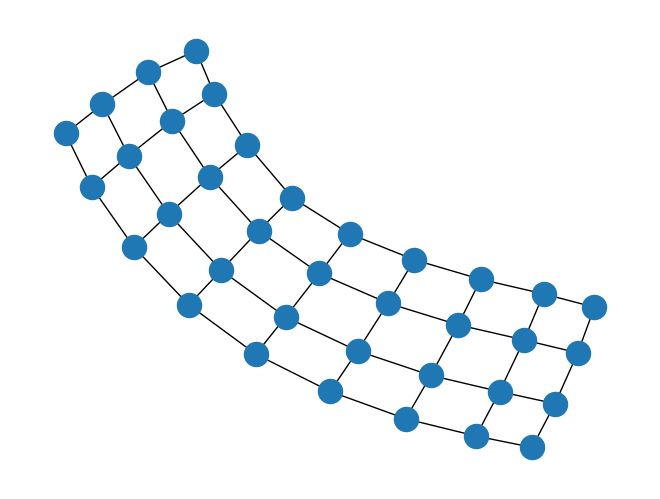

In [130]:
nx.draw_spring(G)

In [4]:
nx.resistance_distance(G,(0,0),(m-1,n-1),weight='res')

<class 'networkx.utils.decorators.argmap'> compilation 20:4: FutureWarning: laplacian_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


2.827490805862467

In [ ]:
# hunch: the modulus (aspect ratio) of a rectangle is a conformal invariant
# the scaling of anisotropic solution to the Laplace equation via x -> a*x, y -> b*y should be related to a/b

In [ ]:
# if first iteration has 2 edges, the second 4, the third 8, and so on, then the kth iteration has 2^(k+1) edges
# 2^(k+1) edges implies 2^(k+1) -1 nodes...

In [107]:
# power of two refinement study

init_m = 20 # => m-1 edges in the x direciton
init_n = 20 # => n-1 edges in the y direction

res_x = 1.0
res_y = 1.0

num_refinement = 4

# recursive relation to determine num edges in refinement
#size_x = [init_m]
#size_y = [init_n]
#for k in range(num_refinement):
#    size_x = size_x + [2*size_x[-1]-1]
#    size_y = size_y + [2*size_y[-1]-1]
size_x = [(init_m-1)*2**k -1 for k in range(num_refinement)]
size_y = [(init_n-1)*2**k -1 for k in range(num_refinement)]

G = [nx.Graph() for g in range(num_refinement)]
factors = [2**k for k in range(num_refinement)]

for k in range(num_refinement):
    for i in range(size_x[k]):
        for j in range(size_y[k]):
            if i < size_x[k]-1:
                G[k].add_edge((i,j),(i+1,j),label=str(i)+"_"+str(i+1)+"__"+str(j),res=res_x/factors[k])
            if j < size_y[k]-1:
                G[k].add_edge((i,j),(i,j+1),label=str(i)+"__"+str(j)+"_"+str(j+1),res=res_y/factors[k])

In [108]:
diag_res = [0 for k in range(num_refinement)]
for k in range(num_refinement):
    diag_res[k] = nx.resistance_distance(G[k],(0,0),(size_x[k]-1,size_y[k]-1),weight='res')
    print(diag_res[k])

3.7582706579379357
2.337538221016847
1.39364069462455
0.8081912071659755


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


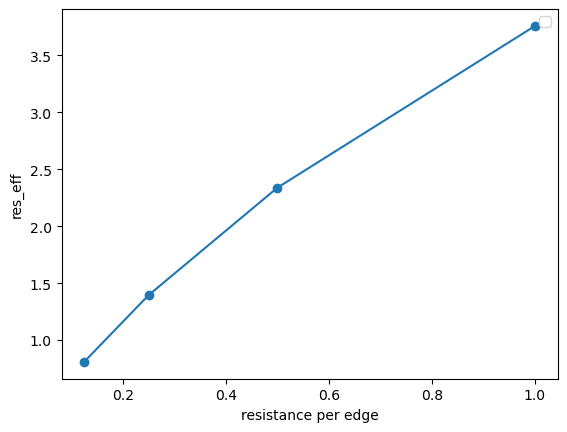

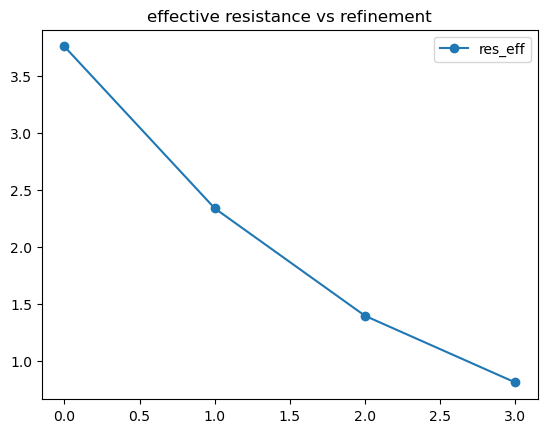

In [109]:
plt.figure()
plt.plot([1./f for f in factors],np.array(diag_res),marker='o')
plt.xlabel('resistance per edge')
plt.ylabel('res_eff')
plt.legend()

plt.figure()
plt.title('effective resistance vs refinement')
plt.plot(diag_res,marker='o',label='res_eff')
plt.legend()

In [110]:
from scipy.optimize import curve_fit

def exponential_model(x, a, b, c):
    return a * np.exp(b * x) + c

xdata = np.array(range(num_refinement))
#xdata = [1/f for f in factors]
ydata = diag_res

popt, pcov = curve_fit(exponential_model, xdata, ydata, p0=(1.0, 0.1, 0.1))
asymptote = popt[2]
print(asymptote)

-0.29912663576312587


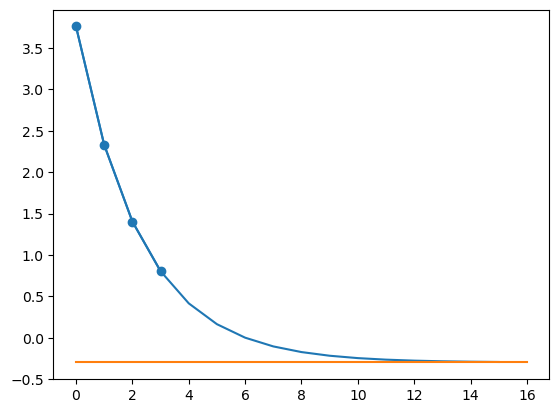

In [111]:
plt.plot([exponential_model(i,popt[0],popt[1],popt[2]) for i in np.array(range(num_refinement))],marker='o',color='tab:blue')
plt.plot([exponential_model(i,popt[0],popt[1],popt[2]) for i in np.array(range(num_refinement*4))],color='tab:blue')
plt.plot((0,num_refinement*4),(asymptote,asymptote),color='tab:orange')